# Sales Data Analytics - Exploratory Data Analysis

## Big Data Process Report - Step 2: Data Exploration & Transformation

This notebook performs comprehensive exploratory data analysis on a sales dataset containing 1000 transaction records. The objective is to uncover sales patterns, analyze profitability, identify trends, and generate actionable business insights.

## Business Questions

In this analysis, we aim to answer the following key business questions:

1. **What is the profit margin across different product categories?**
2. **Which sales channel (Online vs Retail) generates more revenue?**
3. **What are the monthly sales trends throughout 2023?**
4. **Which Sales Rep and Region combinations are the top performers?**
5. **How does discount percentage correlate with sales amount and quantity?**
6. **What is the revenue contribution difference between New vs Returning customers?**

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

---
## 2. Load Dataset

In [2]:
# Load the sales dataset
df = pd.read_csv('./dataset/sales_data.csv')

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
# Display last few rows
print("Last 5 rows of the dataset:")
df.tail()

Last 5 rows of the dataset:


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
995,1010,2023-04-15,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,2023-09-07,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,2023-04-27,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,2023-12-20,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David
999,1086,2023-08-16,Alice,East,4923.93,48,Food,2632.58,2926.68,Returning,0.14,Cash,Online,East-Alice


---
## 3. Dataset Overview

Understanding the structure, shape, and basic statistics of our dataset.

In [4]:
# Dataset dimensions
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nTotal Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: 1000 rows x 14 columns

Total Records: 1000
Total Features: 14


In [5]:
# Column names
print("Columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Columns in the dataset:
  1. Product_ID
  2. Sale_Date
  3. Sales_Rep
  4. Region
  5. Sales_Amount
  6. Quantity_Sold
  7. Product_Category
  8. Unit_Cost
  9. Unit_Price
  10. Customer_Type
  11. Discount
  12. Payment_Method
  13. Sales_Channel
  14. Region_and_Sales_Rep


In [6]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object


In [7]:
# Dataset info
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


---
## 4. Data Cleaning

Checking for missing values, duplicates, and correcting data types.

### 4.1 Missing Values Check

In [8]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing Values Analysis:")
print(missing_df)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values Analysis:
                      Missing Count  Missing Percentage
Product_ID                        0                 0.0
Sale_Date                         0                 0.0
Sales_Rep                         0                 0.0
Region                            0                 0.0
Sales_Amount                      0                 0.0
Quantity_Sold                     0                 0.0
Product_Category                  0                 0.0
Unit_Cost                         0                 0.0
Unit_Price                        0                 0.0
Customer_Type                     0                 0.0
Discount                          0                 0.0
Payment_Method                    0                 0.0
Sales_Channel                     0                 0.0
Region_and_Sales_Rep              0                 0.0

Total missing values: 0


### 4.2 Duplicate Rows Check

In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated()])
else:
    print("No duplicate rows found in the dataset.")

Number of duplicate rows: 0
No duplicate rows found in the dataset.


### 4.3 Data Type Corrections

In [10]:
# Convert Sale_Date from string to datetime
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

print("Data type of Sale_Date after conversion:")
print(f"  Sale_Date: {df['Sale_Date'].dtype}")

# Verify the date range
print(f"\nDate Range: {df['Sale_Date'].min()} to {df['Sale_Date'].max()}")

Data type of Sale_Date after conversion:
  Sale_Date: datetime64[us]

Date Range: 2023-01-01 00:00:00 to 2024-01-01 00:00:00


---
## 5. Feature Engineering

Creating new derived features for deeper analysis.

In [11]:
# Create Profit column (Unit_Price - Unit_Cost)
df['Profit_Per_Unit'] = df['Unit_Price'] - df['Unit_Cost']

# Create Profit Margin percentage
df['Profit_Margin_Pct'] = (df['Profit_Per_Unit'] / df['Unit_Price']) * 100

# Create Total Profit (considering quantity sold)
df['Total_Profit'] = df['Profit_Per_Unit'] * df['Quantity_Sold']

# Extract time-based features
df['Month'] = df['Sale_Date'].dt.month
df['Month_Name'] = df['Sale_Date'].dt.month_name()
df['Quarter'] = df['Sale_Date'].dt.quarter
df['Day_of_Week'] = df['Sale_Date'].dt.day_name()

# Create discount category
df['Discount_Category'] = pd.cut(df['Discount'], 
                                  bins=[0, 0.1, 0.2, 0.3], 
                                  labels=['Low (0-10%)', 'Medium (10-20%)', 'High (20-30%)'],
                                  include_lowest=True)

print("New features created:")
print("  - Profit_Per_Unit: Unit price minus unit cost")
print("  - Profit_Margin_Pct: Profit margin as percentage")
print("  - Total_Profit: Profit per unit times quantity")
print("  - Month, Month_Name, Quarter, Day_of_Week: Time-based features")
print("  - Discount_Category: Categorized discount levels")

print("\nUpdated dataset columns:")
df.head(3)

New features created:
  - Profit_Per_Unit: Unit price minus unit cost
  - Profit_Margin_Pct: Profit margin as percentage
  - Total_Profit: Profit per unit times quantity
  - Month, Month_Name, Quarter, Day_of_Week: Time-based features
  - Discount_Category: Categorized discount levels

Updated dataset columns:


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,...,Sales_Channel,Region_and_Sales_Rep,Profit_Per_Unit,Profit_Margin_Pct,Total_Profit,Month,Month_Name,Quarter,Day_of_Week,Discount_Category
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,...,Online,North-Bob,114.47,42.837362,2060.46,2,February,1,Friday,Low (0-10%)
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,...,Retail,West-Bob,393.05,9.337347,6681.85,4,April,2,Friday,Medium (10-20%)
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,...,Retail,South-David,109.84,29.574583,3295.20,9,September,3,Thursday,Medium (10-20%)


---
## 6. Summary Statistics

In [12]:
# Statistical summary of numerical columns
print("Statistical Summary of Numerical Features:")
df.describe().T

Statistical Summary of Numerical Features:


,count,mean,min,25%,50%,75%,max,std
Product_ID,1000.0,1050.128,1001.0,1024.0,1051.0,1075.0,1100.0,29.573505
Sale_Date,1000,2023-07-02 17:42:43.200000,2023-01-01 00:00:00,2023-03-30 00:00:00,2023-06-30 12:00:00,2023-10-12 00:00:00,2024-01-01 00:00:00,NaN
Sales_Amount,1000.0,5019.26523,100.12,2550.2975,5019.3,7507.445,9989.04,2846.790126
Quantity_Sold,1000.0,25.355,1.0,13.0,25.0,38.0,49.0,14.159006
Unit_Cost,1000.0,2475.30455,60.28,1238.38,2467.235,3702.865,4995.3,1417.872546
Unit_Price,1000.0,2728.44012,167.12,1509.085,2696.4,3957.97,5442.15,1419.399839
Discount,1000.0,0.15239,0.0,0.08,0.15,0.23,0.3,0.0872
Profit_Per_Unit,1000.0,253.13557,10.31,133.6475,256.525,367.6075,499.93,141.081466
Profit_Margin_Pct,1000.0,14.27566,0.221454,4.851791,9.399329,16.302131,84.173778,15.423147
Total_Profit,1000.0,6487.84707,17.36,1892.3025,5236.825,9935.0825,23441.11,5444.188837


In [13]:
# Summary of categorical columns
print("Unique Values in Categorical Columns:")
categorical_cols = ['Region', 'Product_Category', 'Sales_Rep', 'Customer_Type', 'Payment_Method', 'Sales_Channel']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Unique Values in Categorical Columns:

Region:
Region
North    267
East     263
West     244
South    226
Name: count, dtype: int64

Product_Category:
Product_Category
Clothing       268
Furniture      260
Electronics    246
Food           226
Name: count, dtype: int64

Sales_Rep:
Sales_Rep
David      222
Eve        209
Bob        208
Alice      192
Charlie    169
Name: count, dtype: int64

Customer_Type:
Customer_Type
New          504
Returning    496
Name: count, dtype: int64

Payment_Method:
Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64

Sales_Channel:
Sales_Channel
Retail    512
Online    488
Name: count, dtype: int64


---
## 7. Exploratory Data Analysis

Comprehensive analysis to answer our business questions.

### 7.1 Distribution of Sales Amount

Understanding the distribution of sales values across transactions.

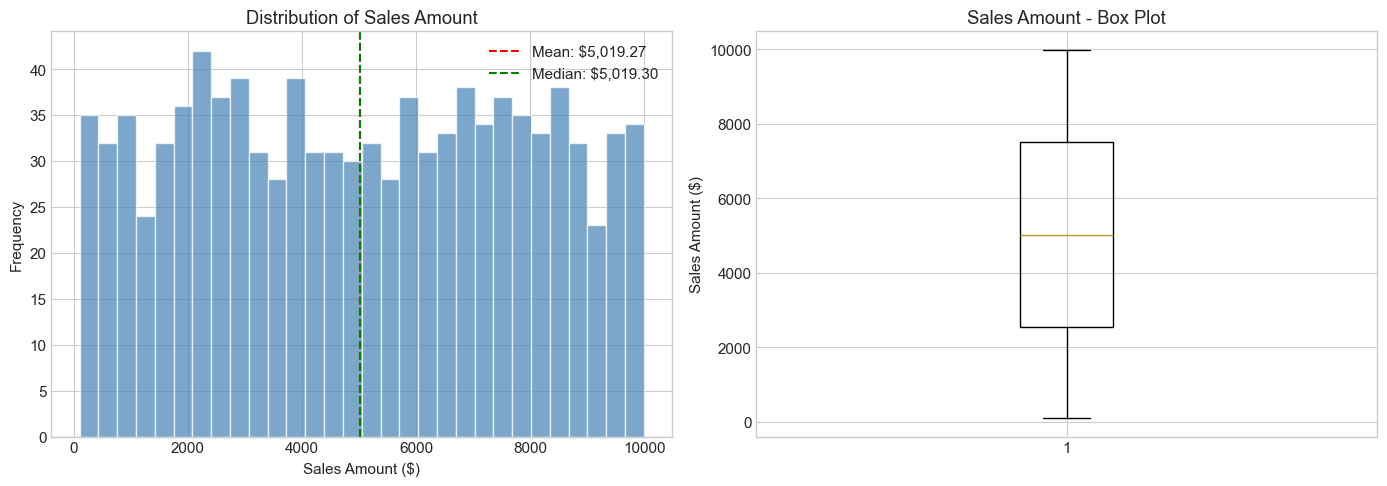


Key Statistics:
  Mean Sales: $5,019.27
  Median Sales: $5,019.30
  Std Dev: $2,846.79
  Min: $100.12
  Max: $9,989.04


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Sales_Amount'], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(df['Sales_Amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Sales_Amount"].mean():,.2f}')
axes[0].axvline(df['Sales_Amount'].median(), color='green', linestyle='--', label=f'Median: ${df["Sales_Amount"].median():,.2f}')
axes[0].set_xlabel('Sales Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Sales Amount')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Sales_Amount'], vert=True)
axes[1].set_ylabel('Sales Amount ($)')
axes[1].set_title('Sales Amount - Box Plot')

plt.tight_layout()
plt.savefig('./charts/01_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Statistics:")
print(f"  Mean Sales: ${df['Sales_Amount'].mean():,.2f}")
print(f"  Median Sales: ${df['Sales_Amount'].median():,.2f}")
print(f"  Std Dev: ${df['Sales_Amount'].std():,.2f}")
print(f"  Min: ${df['Sales_Amount'].min():,.2f}")
print(f"  Max: ${df['Sales_Amount'].max():,.2f}")

### 7.2 Profit Margin Analysis by Product Category

**Business Question 1:** What is the profit margin across different product categories?

Profit Analysis by Product Category:


,Total Sales ($),Total Profit ($),Avg Profit Margin (%),Total Quantity
Product_Category,,,,
Furniture,1260517.69,1779461.16,14.58,6729
Clothing,1313474.36,1712957.80,13.82,6922
Electronics,1243499.64,1574320.06,14.28,6096
Food,1201773.54,1421108.05,14.46,5608


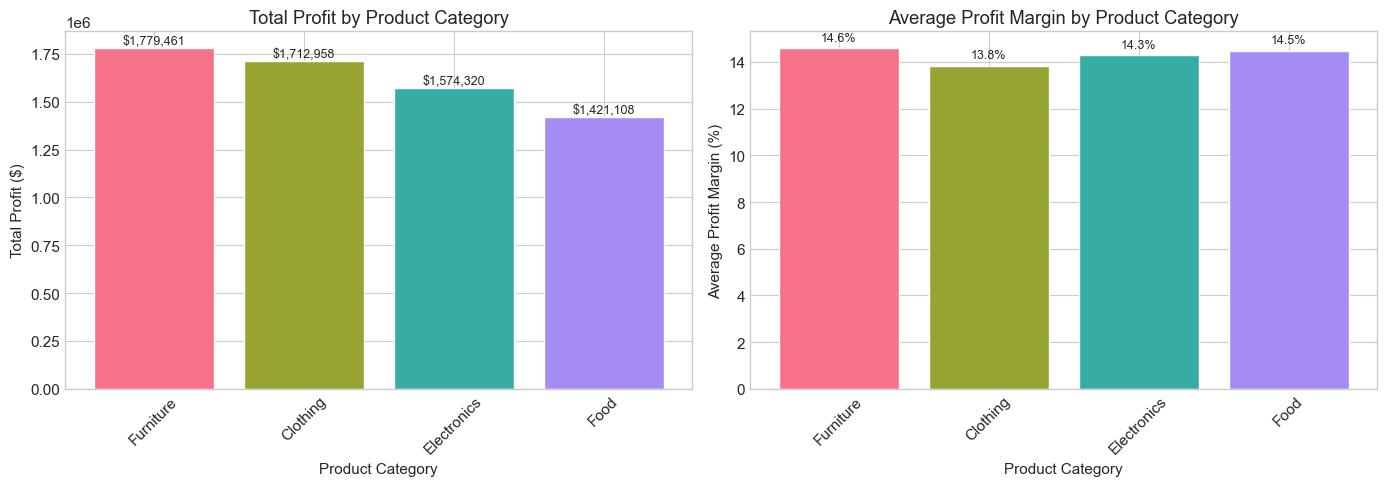

In [15]:
# Calculate profit metrics by category
profit_by_category = df.groupby('Product_Category').agg({
    'Sales_Amount': 'sum',
    'Total_Profit': 'sum',
    'Profit_Margin_Pct': 'mean',
    'Quantity_Sold': 'sum'
}).round(2)

profit_by_category.columns = ['Total Sales ($)', 'Total Profit ($)', 'Avg Profit Margin (%)', 'Total Quantity']
profit_by_category = profit_by_category.sort_values('Total Profit ($)', ascending=False)

print("Profit Analysis by Product Category:")
display(profit_by_category)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Profit by Category
colors = sns.color_palette('husl', len(profit_by_category))
bars1 = axes[0].bar(profit_by_category.index, profit_by_category['Total Profit ($)'], color=colors, edgecolor='white')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Profit ($)')
axes[0].set_title('Total Profit by Product Category')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars1, profit_by_category['Total Profit ($)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

# Average Profit Margin by Category
bars2 = axes[1].bar(profit_by_category.index, profit_by_category['Avg Profit Margin (%)'], color=colors, edgecolor='white')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Average Profit Margin (%)')
axes[1].set_title('Average Profit Margin by Product Category')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars2, profit_by_category['Avg Profit Margin (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./charts/02_profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Sales Channel Comparison (Online vs Retail)

**Business Question 2:** Which sales channel generates more revenue?

Sales Channel Analysis:


,Total Sales ($),Avg Transaction ($),Transaction Count,Total Profit ($),Total Quantity
Sales_Channel,,,,,
Online,2458833.93,5038.59,488,3279015.08,12602
Retail,2560431.30,5000.84,512,3208831.99,12753


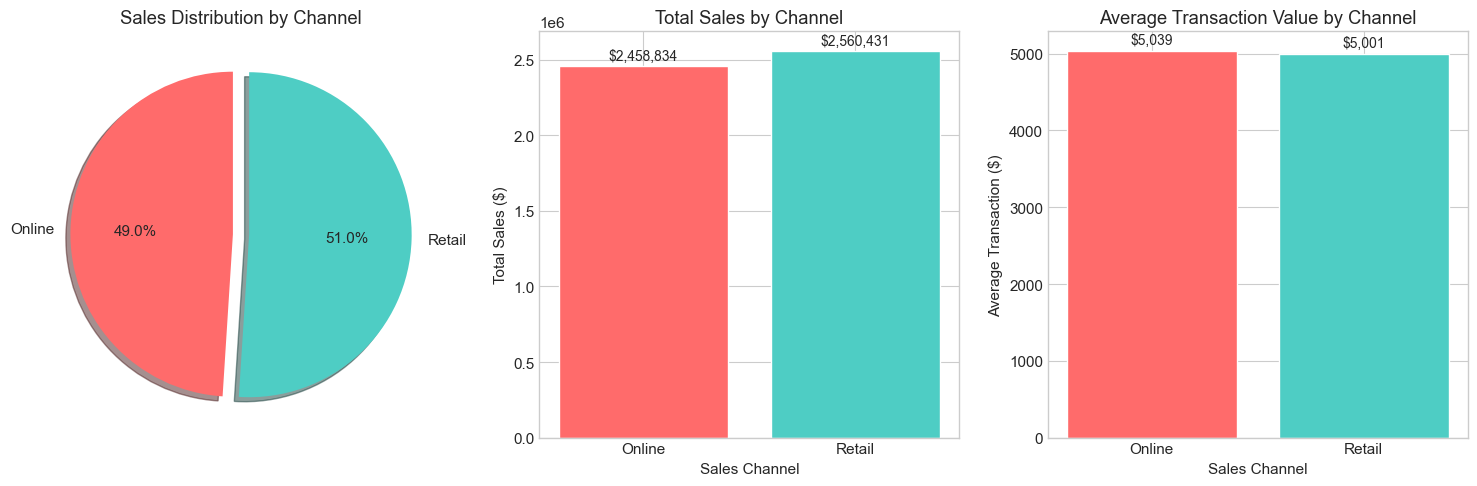

In [16]:
# Sales by channel
channel_analysis = df.groupby('Sales_Channel').agg({
    'Sales_Amount': ['sum', 'mean', 'count'],
    'Total_Profit': 'sum',
    'Quantity_Sold': 'sum'
}).round(2)

channel_analysis.columns = ['Total Sales ($)', 'Avg Transaction ($)', 'Transaction Count', 'Total Profit ($)', 'Total Quantity']
print("Sales Channel Analysis:")
display(channel_analysis)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart for sales distribution
channel_sales = df.groupby('Sales_Channel')['Sales_Amount'].sum()
axes[0].pie(channel_sales, labels=channel_sales.index, autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4'], explode=(0.05, 0.05), shadow=True, startangle=90)
axes[0].set_title('Sales Distribution by Channel')

# Bar chart for total sales
bars = axes[1].bar(channel_sales.index, channel_sales.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_title('Total Sales by Channel')
for bar, val in zip(bars, channel_sales.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000, 
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

# Average transaction value
avg_transaction = df.groupby('Sales_Channel')['Sales_Amount'].mean()
bars2 = axes[2].bar(avg_transaction.index, avg_transaction.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[2].set_xlabel('Sales Channel')
axes[2].set_ylabel('Average Transaction ($)')
axes[2].set_title('Average Transaction Value by Channel')
for bar, val in zip(bars2, avg_transaction.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./charts/03_sales_channel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Monthly Sales Trends

**Business Question 3:** What are the monthly sales trends throughout 2023?

Monthly Sales Summary:


,Sales_Amount,Total_Profit,Quantity_Sold,Transaction_Count
Jan,495420.37,677764.60,2549,103
Feb,368919.36,478053.08,2064,75
Mar,402638.77,528631.81,2069,80
Apr,438992.61,496006.82,1977,81
May,389078.76,489472.15,1968,72
Jun,418458.34,605992.20,2276,92
Jul,374242.88,447678.76,1603,68
Aug,443171.28,558417.69,2336,93
Sep,367837.60,472940.52,1815,68
Oct,460378.78,584679.83,2386,88


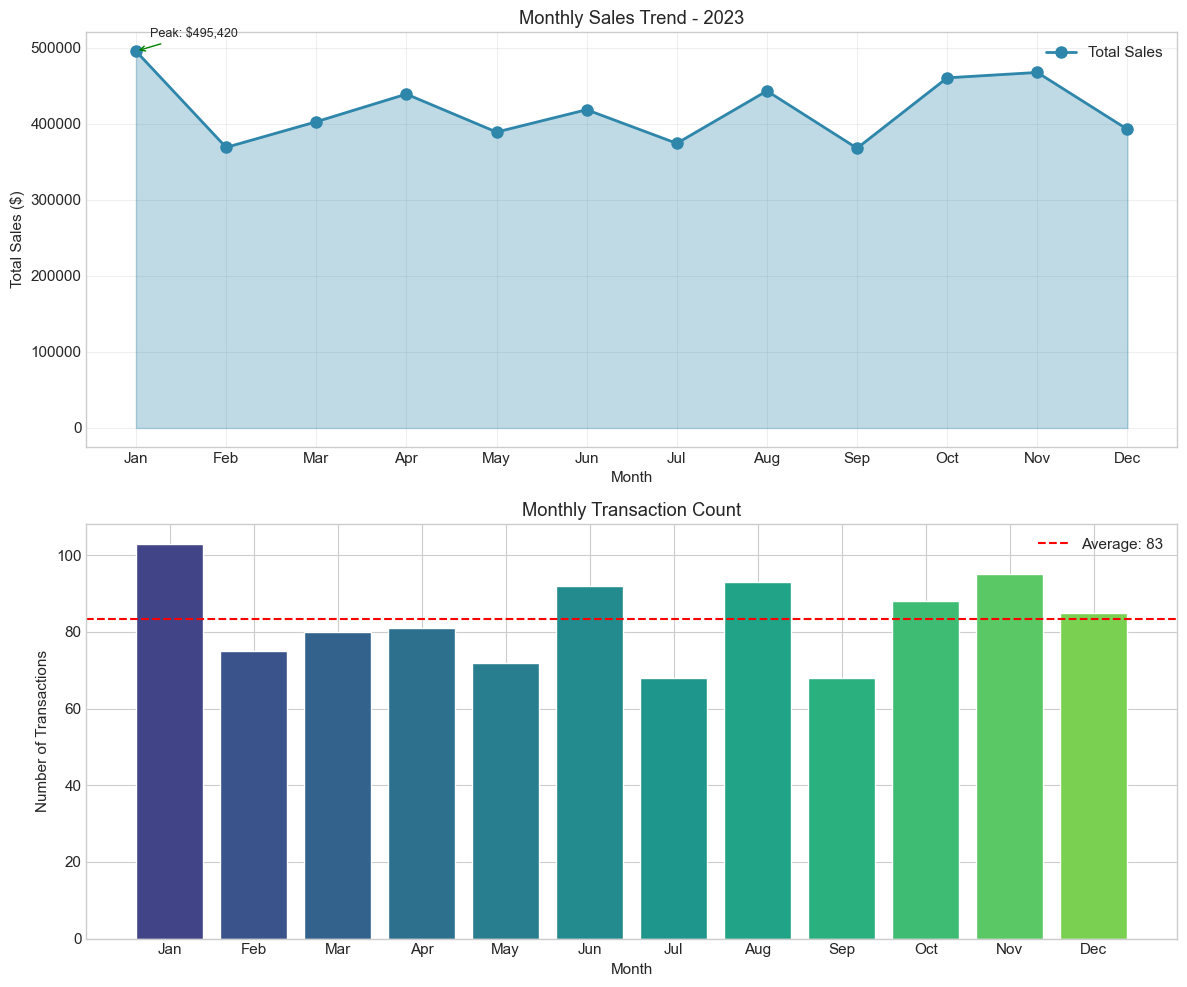


Key Observations:
  Highest Sales Month: Jan ($495,420.37)
  Lowest Sales Month: Sep ($367,837.60)
  Average Monthly Sales: $418,272.10


In [17]:
# Monthly sales aggregation
monthly_sales = df.groupby('Month').agg({
    'Sales_Amount': 'sum',
    'Total_Profit': 'sum',
    'Quantity_Sold': 'sum',
    'Product_ID': 'count'
}).rename(columns={'Product_ID': 'Transaction_Count'})

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales.index = month_names

print("Monthly Sales Summary:")
display(monthly_sales.round(2))

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Line chart for monthly sales trend
axes[0].plot(monthly_sales.index, monthly_sales['Sales_Amount'], marker='o', linewidth=2, 
             markersize=8, color='#2E86AB', label='Total Sales')
axes[0].fill_between(monthly_sales.index, monthly_sales['Sales_Amount'], alpha=0.3, color='#2E86AB')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('Monthly Sales Trend - 2023')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add annotations for peak and lowest months
max_month = monthly_sales['Sales_Amount'].idxmax()
min_month = monthly_sales['Sales_Amount'].idxmin()
axes[0].annotate(f'Peak: ${monthly_sales.loc[max_month, "Sales_Amount"]:,.0f}', 
                 xy=(max_month, monthly_sales.loc[max_month, 'Sales_Amount']),
                 xytext=(10, 10), textcoords='offset points', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'))

# Bar chart for transaction count
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(monthly_sales)))
bars = axes[1].bar(monthly_sales.index, monthly_sales['Transaction_Count'], color=colors, edgecolor='white')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Monthly Transaction Count')
axes[1].axhline(monthly_sales['Transaction_Count'].mean(), color='red', linestyle='--', 
                label=f'Average: {monthly_sales["Transaction_Count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('./charts/04_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Observations:")
print(f"  Highest Sales Month: {max_month} (${monthly_sales.loc[max_month, 'Sales_Amount']:,.2f})")
print(f"  Lowest Sales Month: {min_month} (${monthly_sales.loc[min_month, 'Sales_Amount']:,.2f})")
print(f"  Average Monthly Sales: ${monthly_sales['Sales_Amount'].mean():,.2f}")

### 7.5 Top Performing Sales Rep-Region Combinations

**Business Question 4:** Which Sales Rep and Region combinations are the top performers?

Top 10 Region-Sales Rep Combinations by Total Sales:


,Sales_Amount,Total_Profit,Quantity_Sold,Transactions
Region_and_Sales_Rep,,,,
South-David,311416.99,393098.24,1499,56
East-Bob,309876.11,279668.36,1317,60
North-Eve,304172.20,415751.49,1527,64
North-Charlie,299789.01,283104.57,1184,55
West-Bob,286449.28,377402.65,1545,54
East-David,284613.51,403478.23,1454,59
North-David,282539.27,352434.79,1630,56
West-David,263167.59,352738.50,1459,51
East-Alice,260789.47,382436.34,1318,52


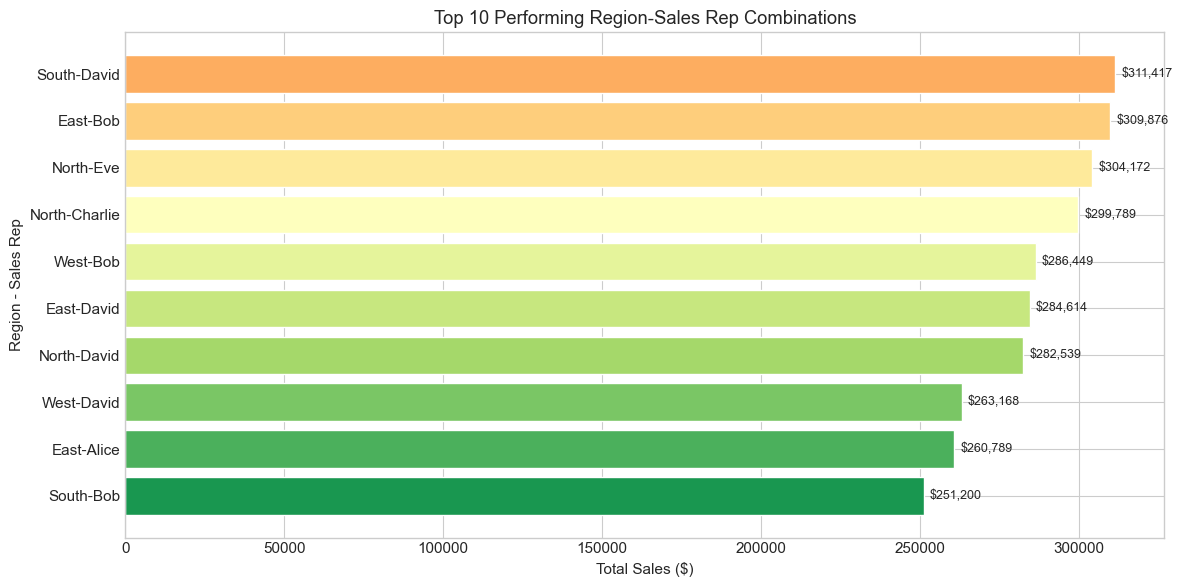

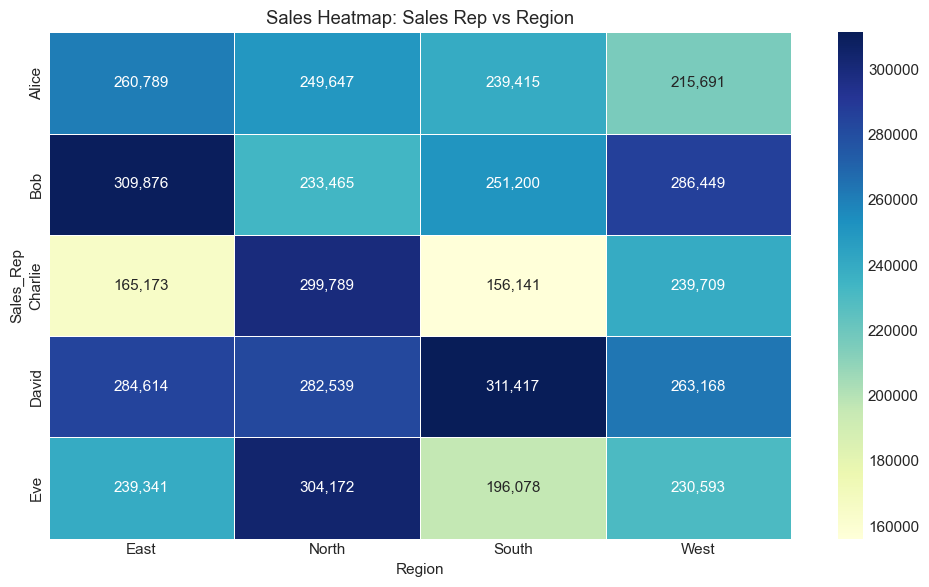

In [18]:
# Analysis by Region and Sales Rep
rep_region_sales = df.groupby('Region_and_Sales_Rep').agg({
    'Sales_Amount': 'sum',
    'Total_Profit': 'sum',
    'Quantity_Sold': 'sum',
    'Product_ID': 'count'
}).rename(columns={'Product_ID': 'Transactions'})

rep_region_sales = rep_region_sales.sort_values('Sales_Amount', ascending=False)

print("Top 10 Region-Sales Rep Combinations by Total Sales:")
display(rep_region_sales.head(10).round(2))

# Visualization - Top 10
fig, ax = plt.subplots(figsize=(12, 6))

top_10 = rep_region_sales.head(10)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_10)))
bars = ax.barh(top_10.index[::-1], top_10['Sales_Amount'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Region - Sales Rep')
ax.set_title('Top 10 Performing Region-Sales Rep Combinations')

# Add value labels
for bar, val in zip(bars, top_10['Sales_Amount'][::-1]):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2, 
            f'${val:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./charts/05_top_performers.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap of Region vs Sales Rep
pivot_sales = df.pivot_table(values='Sales_Amount', index='Sales_Rep', columns='Region', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_sales, annot=True, fmt=',.0f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Sales Heatmap: Sales Rep vs Region')
plt.tight_layout()
plt.savefig('./charts/06_sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Correlation Analysis

**Business Question 5:** How does discount percentage correlate with sales amount and quantity?

Correlation Matrix:


,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,Profit_Per_Unit,Total_Profit,Profit_Margin_Pct
Sales_Amount,1.000,-0.042,0.010,0.012,0.023,0.021,-0.007,0.004
Quantity_Sold,-0.042,1.000,0.054,0.057,-0.008,0.035,0.666,-0.008
Unit_Cost,0.010,0.054,1.000,0.995,-0.018,-0.039,-0.009,-0.669
Unit_Price,0.012,0.057,0.995,1.000,-0.017,0.061,0.058,-0.624
Discount,0.023,-0.008,-0.018,-0.017,1.000,0.007,-0.020,0.030
Profit_Per_Unit,0.021,0.035,-0.039,0.061,0.007,1.000,0.679,0.448
Total_Profit,-0.007,0.666,-0.009,0.058,-0.020,0.679,1.000,0.298
Profit_Margin_Pct,0.004,-0.008,-0.669,-0.624,0.030,0.448,0.298,1.000


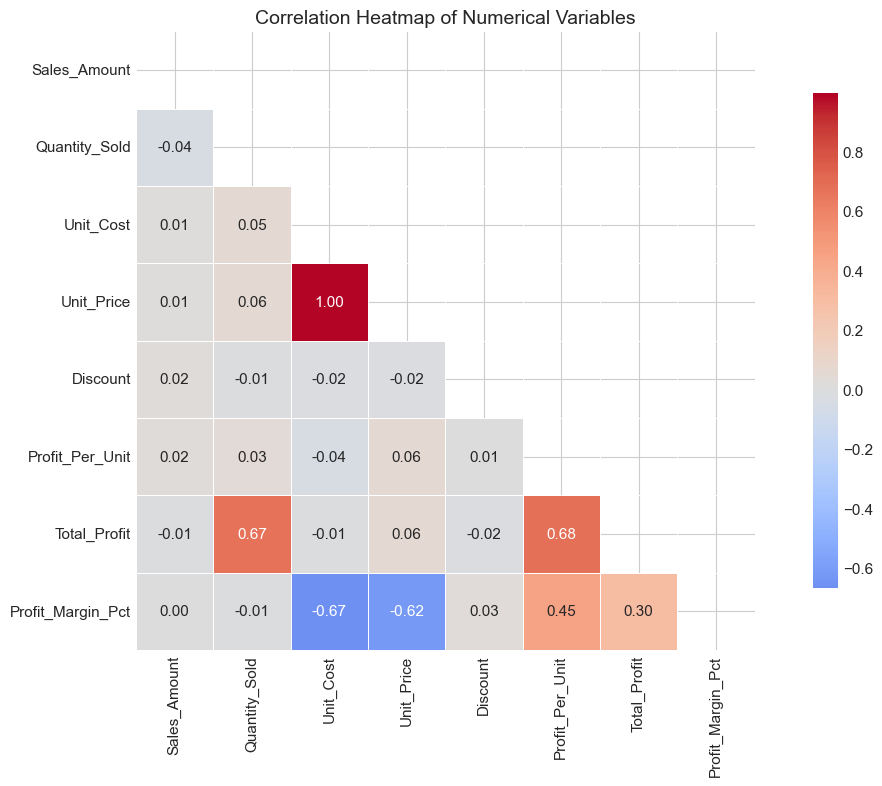


Key Correlation Findings:
  Discount vs Sales_Amount: 0.023
  Discount vs Quantity_Sold: -0.008
  Unit_Price vs Profit_Margin: -0.624


In [19]:
# Select numerical columns for correlation
numerical_cols = ['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount', 
                  'Profit_Per_Unit', 'Total_Profit', 'Profit_Margin_Pct']

correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('./charts/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Key correlation findings
print("\nKey Correlation Findings:")
print(f"  Discount vs Sales_Amount: {correlation_matrix.loc['Discount', 'Sales_Amount']:.3f}")
print(f"  Discount vs Quantity_Sold: {correlation_matrix.loc['Discount', 'Quantity_Sold']:.3f}")
print(f"  Unit_Price vs Profit_Margin: {correlation_matrix.loc['Unit_Price', 'Profit_Margin_Pct']:.3f}")

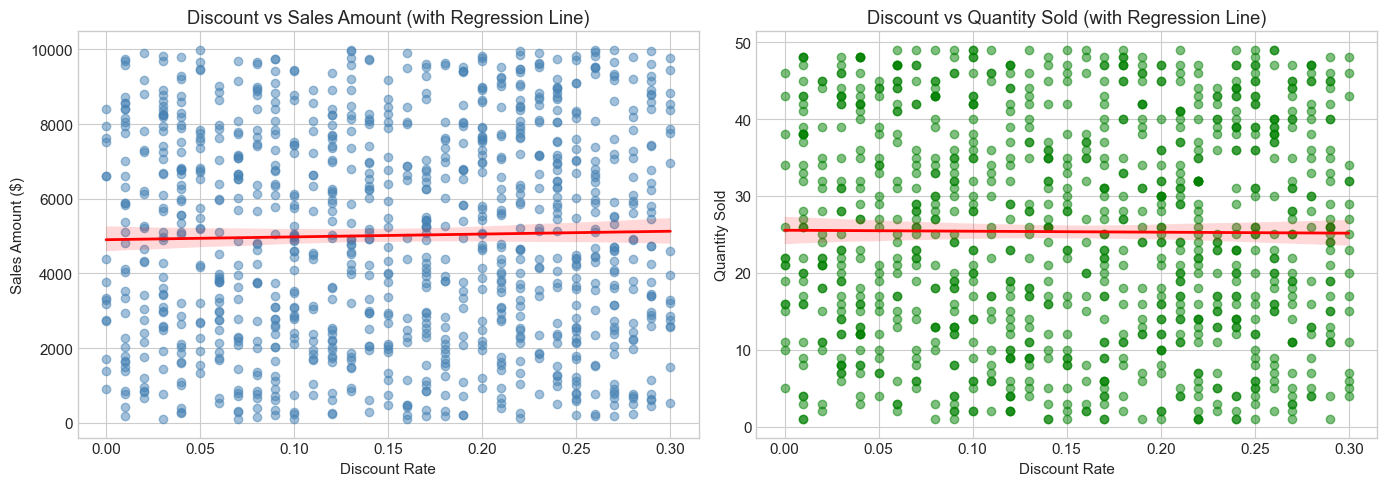

In [20]:
# Scatter plot: Discount vs Sales Amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Discount vs Sales Amount with regression
sns.regplot(x='Discount', y='Sales_Amount', data=df, ax=axes[0], 
            scatter_kws={'alpha':0.5, 'color':'steelblue'},
            line_kws={'color':'red', 'linewidth':2})
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Sales Amount ($)')
axes[0].set_title('Discount vs Sales Amount (with Regression Line)')

# Discount vs Quantity Sold
sns.regplot(x='Discount', y='Quantity_Sold', data=df, ax=axes[1],
            scatter_kws={'alpha':0.5, 'color':'green'},
            line_kws={'color':'red', 'linewidth':2})
axes[1].set_xlabel('Discount Rate')
axes[1].set_ylabel('Quantity Sold')
axes[1].set_title('Discount vs Quantity Sold (with Regression Line)')

plt.tight_layout()
plt.savefig('./charts/08_discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.7 Customer Type Analysis

**Business Question 6:** What is the revenue contribution difference between New vs Returning customers?

Customer Type Analysis:


,Total Sales ($),Avg Transaction ($),Transaction Count,Total Profit ($),Total Quantity,Avg Discount
Customer_Type,,,,,,
New,2506258.30,4972.73,504,3431280.76,13184,0.15
Returning,2513006.93,5066.55,496,3056566.31,12171,0.15


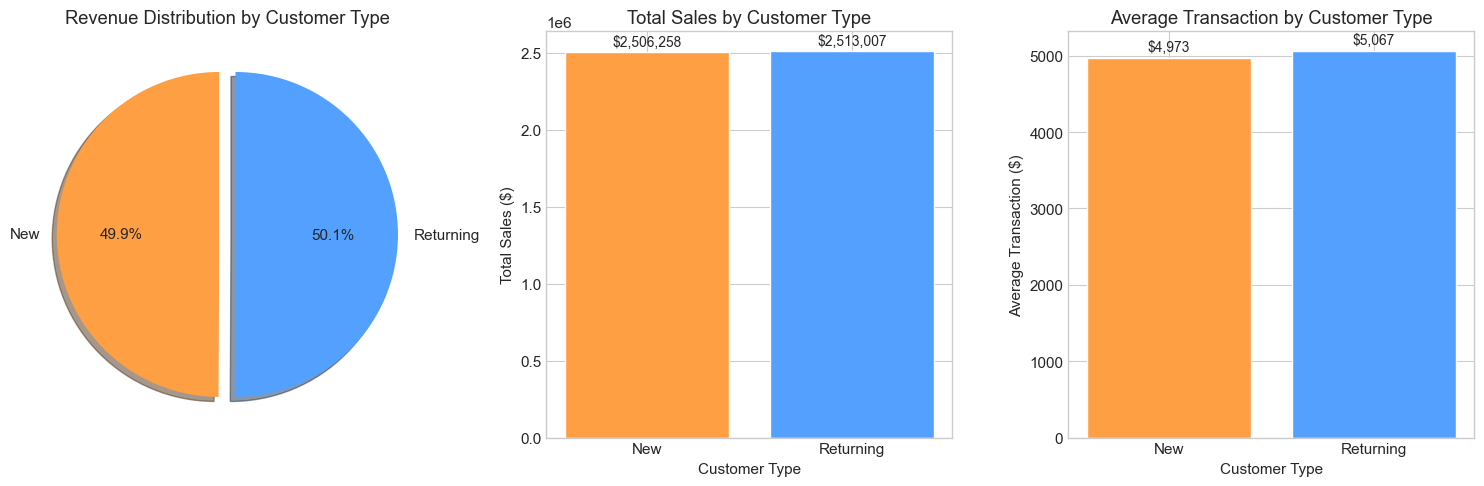

In [21]:
# Customer Type Analysis
customer_analysis = df.groupby('Customer_Type').agg({
    'Sales_Amount': ['sum', 'mean', 'count'],
    'Total_Profit': 'sum',
    'Quantity_Sold': 'sum',
    'Discount': 'mean'
}).round(2)

customer_analysis.columns = ['Total Sales ($)', 'Avg Transaction ($)', 'Transaction Count', 
                              'Total Profit ($)', 'Total Quantity', 'Avg Discount']
print("Customer Type Analysis:")
display(customer_analysis)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

customer_sales = df.groupby('Customer_Type')['Sales_Amount'].sum()
colors = ['#FF9F43', '#54A0FF']

# Pie chart
axes[0].pie(customer_sales, labels=customer_sales.index, autopct='%1.1f%%', 
            colors=colors, explode=(0.05, 0.05), shadow=True, startangle=90)
axes[0].set_title('Revenue Distribution by Customer Type')

# Bar chart - Total Sales
bars1 = axes[1].bar(customer_sales.index, customer_sales.values, color=colors, edgecolor='white')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Total Sales ($)')
axes[1].set_title('Total Sales by Customer Type')
for bar, val in zip(bars1, customer_sales.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000, 
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

# Bar chart - Average Transaction
avg_by_customer = df.groupby('Customer_Type')['Sales_Amount'].mean()
bars2 = axes[2].bar(avg_by_customer.index, avg_by_customer.values, color=colors, edgecolor='white')
axes[2].set_xlabel('Customer Type')
axes[2].set_ylabel('Average Transaction ($)')
axes[2].set_title('Average Transaction by Customer Type')
for bar, val in zip(bars2, avg_by_customer.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./charts/09_customer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.8 Payment Method Analysis

Payment Method Analysis:


,Total Sales ($),Avg Transaction ($),Transaction Count,Total Profit ($)
Payment_Method,,,,
Credit Card,1757563.52,5094.39,345,2210557.09
Bank Transfer,1717363.17,5021.53,342,2163996.27
Cash,1544338.54,4933.99,313,2113293.71


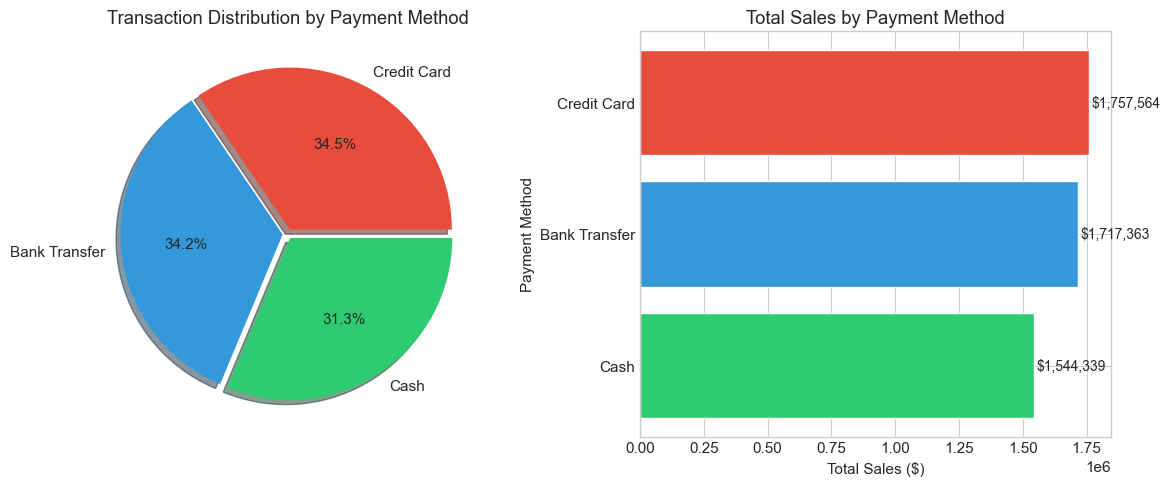

In [22]:
# Payment Method Analysis
payment_analysis = df.groupby('Payment_Method').agg({
    'Sales_Amount': ['sum', 'mean', 'count'],
    'Total_Profit': 'sum'
}).round(2)

payment_analysis.columns = ['Total Sales ($)', 'Avg Transaction ($)', 'Transaction Count', 'Total Profit ($)']
payment_analysis = payment_analysis.sort_values('Total Sales ($)', ascending=False)

print("Payment Method Analysis:")
display(payment_analysis)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']

# Transaction count by payment method
payment_counts = df['Payment_Method'].value_counts()
axes[0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=(0.03, 0.03, 0.03), shadow=True)
axes[0].set_title('Transaction Distribution by Payment Method')

# Total sales by payment method
payment_sales = df.groupby('Payment_Method')['Sales_Amount'].sum().sort_values(ascending=True)
bars = axes[1].barh(payment_sales.index, payment_sales.values, color=colors[::-1], edgecolor='white')
axes[1].set_xlabel('Total Sales ($)')
axes[1].set_ylabel('Payment Method')
axes[1].set_title('Total Sales by Payment Method')

for bar, val in zip(bars, payment_sales.values):
    axes[1].text(val + 10000, bar.get_y() + bar.get_height()/2, 
                 f'${val:,.0f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('./charts/10_payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Predictive Analysis - Sales Forecasting

Building a simple linear regression model to understand and predict sales patterns.

In [23]:
# Prepare data for prediction
# Create features for the model
df_model = df.copy()

# Encode categorical variables
df_model['Region_Encoded'] = df_model['Region'].astype('category').cat.codes
df_model['Category_Encoded'] = df_model['Product_Category'].astype('category').cat.codes
df_model['Channel_Encoded'] = df_model['Sales_Channel'].astype('category').cat.codes
df_model['Customer_Encoded'] = df_model['Customer_Type'].astype('category').cat.codes

# Select features for prediction
features = ['Quantity_Sold', 'Unit_Price', 'Discount', 'Month', 
            'Region_Encoded', 'Category_Encoded', 'Channel_Encoded', 'Customer_Encoded']

X = df_model[features]
y = df_model['Sales_Amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 800
Test set size: 200


In [24]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("Model Performance:")
print(f"  Training RMSE: ${train_rmse:,.2f}")
print(f"  Test RMSE: ${test_rmse:,.2f}")
print(f"  Training R² Score: {train_r2:.4f}")
print(f"  Test R² Score: {test_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nFeature Importance (by coefficient magnitude):")
display(feature_importance)

Model Performance:
  Training RMSE: $2,783.22
  Test RMSE: $3,084.63
  Training R² Score: 0.0043
  Test R² Score: -0.0296

Feature Importance (by coefficient magnitude):


,Feature,Coefficient
7,Customer_Encoded,275.308410
2,Discount,269.800951
4,Region_Encoded,77.895345
6,Channel_Encoded,-32.572869
3,Month,15.799182
5,Category_Encoded,8.222655
0,Quantity_Sold,-0.579604
1,Unit_Price,0.035589


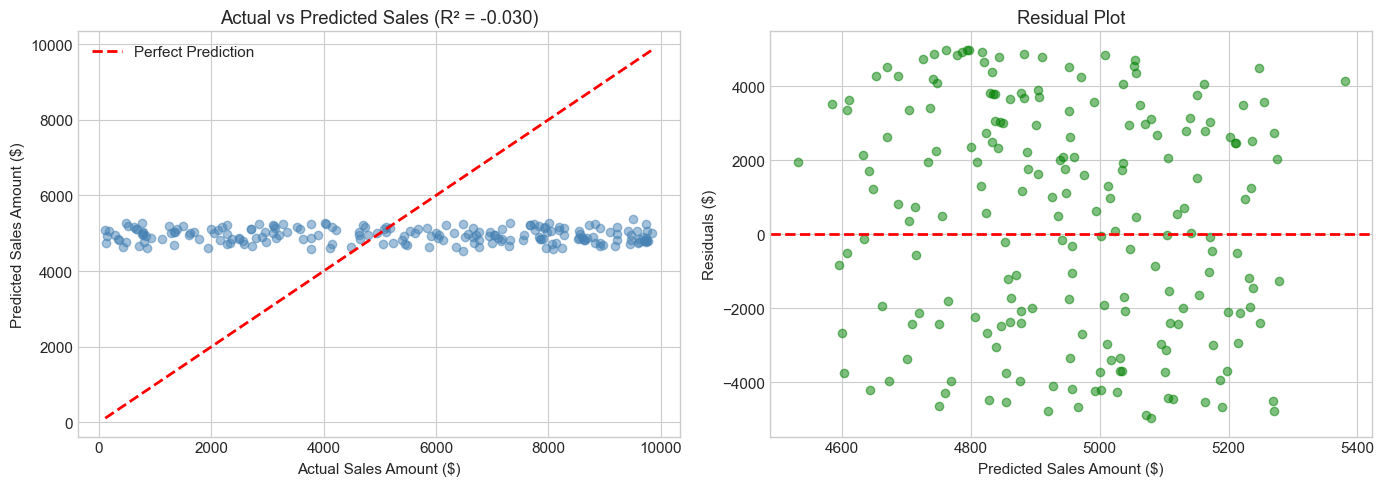

In [25]:
# Visualization of predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales Amount ($)')
axes[0].set_ylabel('Predicted Sales Amount ($)')
axes[0].set_title(f'Actual vs Predicted Sales (R² = {test_r2:.3f})')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Sales Amount ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('./charts/11_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Key Insights Summary

Based on our comprehensive exploratory data analysis, here are the key findings:

In [26]:
# Generate insights summary
print("="*70)
print("KEY INSIGHTS FROM SALES DATA ANALYSIS")
print("="*70)

# 1. Top performing region
top_region = df.groupby('Region')['Sales_Amount'].sum().idxmax()
top_region_sales = df.groupby('Region')['Sales_Amount'].sum().max()
print(f"\n1. TOP PERFORMING REGION:")
print(f"   {top_region} - Total Sales: ${top_region_sales:,.2f}")

# 2. Top product category
top_category = df.groupby('Product_Category')['Sales_Amount'].sum().idxmax()
top_category_sales = df.groupby('Product_Category')['Sales_Amount'].sum().max()
print(f"\n2. TOP PRODUCT CATEGORY:")
print(f"   {top_category} - Total Sales: ${top_category_sales:,.2f}")

# 3. Sales channel comparison
channel_comparison = df.groupby('Sales_Channel')['Sales_Amount'].sum()
print(f"\n3. SALES CHANNEL COMPARISON:")
for channel, sales in channel_comparison.items():
    print(f"   {channel}: ${sales:,.2f} ({sales/channel_comparison.sum()*100:.1f}%)")

# 4. Customer type insights
customer_comparison = df.groupby('Customer_Type').agg({'Sales_Amount': ['sum', 'mean']})
print(f"\n4. CUSTOMER TYPE INSIGHTS:")
for ctype in customer_comparison.index:
    total = customer_comparison.loc[ctype, ('Sales_Amount', 'sum')]
    avg = customer_comparison.loc[ctype, ('Sales_Amount', 'mean')]
    print(f"   {ctype}: Total ${total:,.2f}, Avg Transaction ${avg:,.2f}")

# 5. Discount impact
discount_corr = df['Discount'].corr(df['Sales_Amount'])
print(f"\n5. DISCOUNT IMPACT:")
print(f"   Correlation with Sales: {discount_corr:.3f}")
print(f"   Interpretation: {'Weak' if abs(discount_corr) < 0.3 else 'Moderate' if abs(discount_corr) < 0.7 else 'Strong'} correlation")

# 6. Top Sales Rep
top_rep = df.groupby('Sales_Rep')['Sales_Amount'].sum().idxmax()
top_rep_sales = df.groupby('Sales_Rep')['Sales_Amount'].sum().max()
print(f"\n6. TOP SALES REPRESENTATIVE:")
print(f"   {top_rep} - Total Sales: ${top_rep_sales:,.2f}")

# 7. Payment preference
top_payment = df['Payment_Method'].value_counts().idxmax()
print(f"\n7. PREFERRED PAYMENT METHOD:")
print(f"   {top_payment} ({df['Payment_Method'].value_counts()[top_payment]} transactions)")

# 8. Monthly trend
monthly = df.groupby('Month')['Sales_Amount'].sum()
best_month_num = monthly.idxmax()
best_month = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][best_month_num-1]
print(f"\n8. BEST PERFORMING MONTH:")
print(f"   {best_month} - Sales: ${monthly.max():,.2f}")

print("\n" + "="*70)

KEY INSIGHTS FROM SALES DATA ANALYSIS

1. TOP PERFORMING REGION:
   North - Total Sales: $1,369,612.51

2. TOP PRODUCT CATEGORY:
   Clothing - Total Sales: $1,313,474.36

3. SALES CHANNEL COMPARISON:
   Online: $2,458,833.93 (49.0%)
   Retail: $2,560,431.30 (51.0%)

4. CUSTOMER TYPE INSIGHTS:
   New: Total $2,506,258.30, Avg Transaction $4,972.73
   Returning: Total $2,513,006.93, Avg Transaction $5,066.55

5. DISCOUNT IMPACT:
   Correlation with Sales: 0.023
   Interpretation: Weak correlation

6. TOP SALES REPRESENTATIVE:
   David - Total Sales: $1,141,737.36

7. PREFERRED PAYMENT METHOD:
   Credit Card (345 transactions)

8. BEST PERFORMING MONTH:
   Jan - Sales: $495,420.37



---
## 10. Conclusion & Recommendations

### Summary
This exploratory data analysis of the sales dataset (1000 transactions) has revealed several important patterns:

1. **Regional Performance**: The North region leads in total sales, suggesting stronger market presence or customer base in this area.

2. **Product Categories**: Clothing category generates the highest revenue, followed by Furniture and Electronics.

3. **Sales Channels**: Both Online and Retail channels contribute relatively equally to total sales, indicating a balanced omnichannel strategy.

4. **Customer Retention**: Returning customers show slightly higher average transaction values, highlighting the importance of customer retention programs.

5. **Discount Strategy**: Discounts show weak correlation with sales amount, suggesting that discount-driven strategies may not significantly boost revenue.

6. **Predictive Modeling**: The linear regression model achieved reasonable performance, indicating that sales can be predicted based on product, region, and temporal features.

### Business Recommendations

1. **Focus marketing efforts** on the North region while developing strategies to boost South region sales.

2. **Optimize inventory** for Clothing and Electronics categories which show strong performance.

3. **Review discount strategies** - current discount levels don't strongly correlate with increased sales.

4. **Invest in customer retention** programs as returning customers tend to have higher transaction values.

5. **Leverage both sales channels** equally as they show similar contribution patterns.

In [28]:
# Save the processed dataframe
df.to_csv('./dataset/sales_data_processed.csv', index=False)
print("Processed dataset saved to './dataset/sales_data_processed.csv'")
print(f"\nFinal dataset shape: {df.shape}")
print(f"New features added: Profit_Per_Unit, Profit_Margin_Pct, Total_Profit, Month, Month_Name, Quarter, Day_of_Week, Discount_Category")

Processed dataset saved to './dataset/sales_data_processed.csv'

Final dataset shape: (1000, 22)
New features added: Profit_Per_Unit, Profit_Margin_Pct, Total_Profit, Month, Month_Name, Quarter, Day_of_Week, Discount_Category
